In [1]:
# Скользящее среднее: какое максимальное значение получилось?
# Построить графики скользящего среднего для: window = 2 \ 4 \ 10 \ 50
# получить экспоненциальное скользящее среднее
# Для avocado_mean применить: ewm(span=2) и получить экспоненциальное скользящее среднее.
# avocado_full Посчитать два показателя Обычное скользящее среднее: window = 4 и Экспоненциальное скользящее среднее: span = 4. Построить графики обоих вариантов. Заполнить пропуски. Округлить до 3 знаков.
# delays.csv Перевести delay в timedelta. Разбить задержку на 3 интервала
# Пересоздать delay_categorical, но теперь категории должны называться: less than 1 day до more than 6 days
# Построить интерактивный barplot, показывающий, насколько часто происходят задержки каждой категории. Отсортировать по частоте.

In [2]:
from operator import index

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
avocado_mean = pd.read_csv('avocado_mean_1000.csv', index_col=0,  parse_dates=['Date'])
avocado_mean.head()

,AveragePrice
Date,
2015-01-04,1.3713
2015-01-11,1.2818
2015-01-18,1.4117
2015-01-25,1.4297
2015-02-01,1.2318


In [4]:
print(avocado_mean['AveragePrice'].rolling(3).mean().max().round(2))

1.66


In [5]:
sns.set(rc = {'figure.figsize' : (9,6)})

Text(0.5, 0, '\nDate')

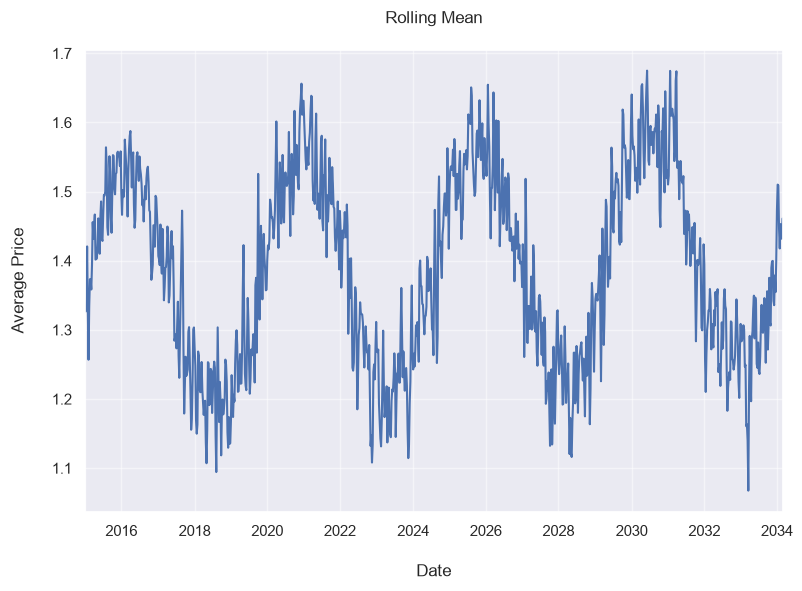

In [6]:
avocado_window_2 = avocado_mean['AveragePrice'].rolling(2).mean().plot()
avocado_window_2.set_title('Rolling Mean\n')
avocado_window_2.set_ylabel('Average Price\n')
avocado_window_2.set_xlabel('\nDate')
#print(avocado_window_2)

Text(0.5, 0, '\nDate')

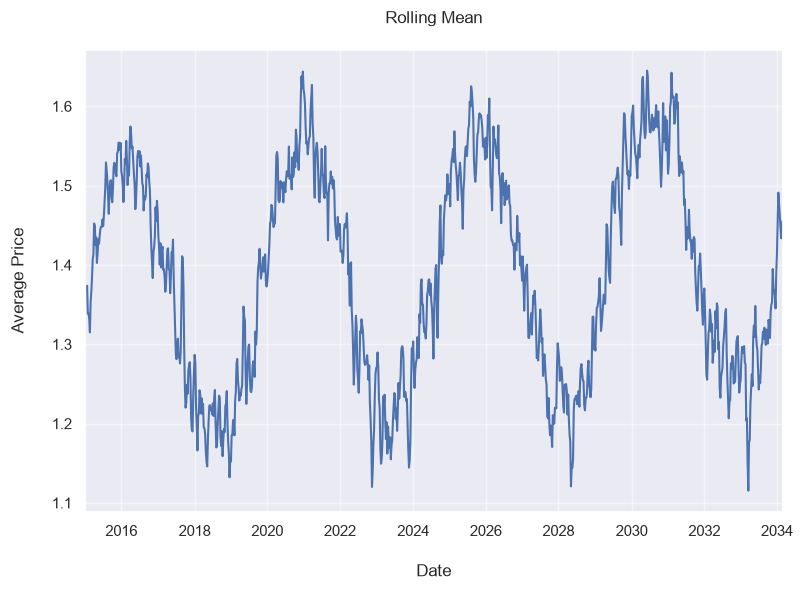

In [7]:
avocado_window_4 = avocado_mean['AveragePrice'].rolling(4).mean().plot()
avocado_window_4.set_title('Rolling Mean\n')
avocado_window_4.set_ylabel('Average Price\n')
avocado_window_4.set_xlabel('\nDate')

Text(0.5, 0, '\nDate')

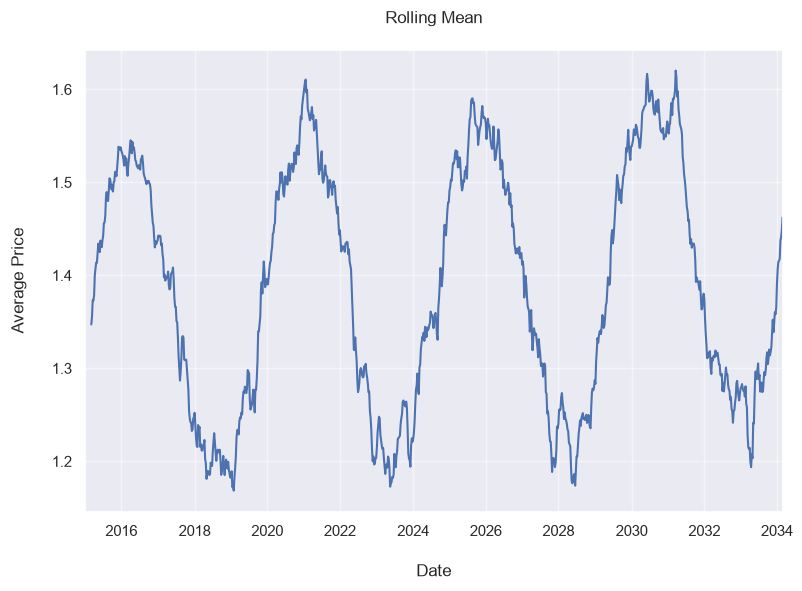

In [8]:
avocado_window_10 = avocado_mean['AveragePrice'].rolling(10).mean().plot()
avocado_window_10.set_title('Rolling Mean\n')
avocado_window_10.set_ylabel('Average Price\n')
avocado_window_10.set_xlabel('\nDate')

Text(0.5, 0, '\nDate')

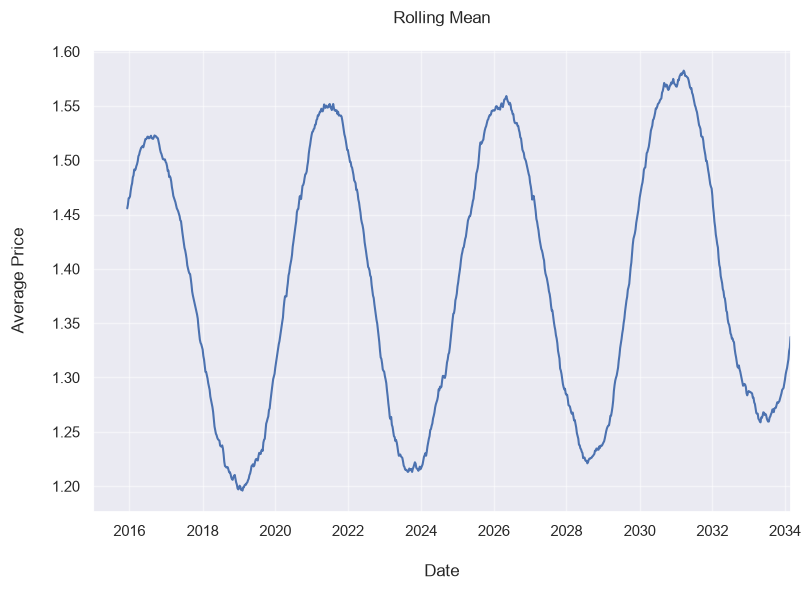

In [9]:
avocado_window_50 = avocado_mean['AveragePrice'].rolling(50).mean().plot()
avocado_window_50.set_title('Rolling Mean\n')
avocado_window_50.set_ylabel('Average Price\n')
avocado_window_50.set_xlabel('\nDate')

In [10]:
avocado_ewm = avocado_mean.ewm(span=2).mean()
avocado_ewm

,AveragePrice
Date,
2015-01-04,1.371300
2015-01-11,1.304175
2015-01-18,1.378615
2015-01-25,1.413097
2015-02-01,1.291733
...,...
2034-01-29,1.434888
2034-02-05,1.458163
2034-02-12,1.438854


In [11]:
avocado_rolling = avocado_mean.rolling(2).mean()
avocado_rolling

,AveragePrice
Date,
2015-01-04,NaN
2015-01-11,1.32655
2015-01-18,1.34675
2015-01-25,1.42070
2015-02-01,1.33075
...,...
2034-01-29,1.41775
2034-02-05,1.45300
2034-02-12,1.44950


In [47]:
np.random.seed(42)

dates = pd.date_range('2016-01-03', periods=50, freq='7D')
regions = ['Chicago', 'NewYork', 'LosAngeles', 'Houston', 'Dallas']
types = ['organic', 'conventional']

data = []

for date in dates:
    for region in regions:
        for avocado_type in types:

            # базовая цена + сезонность + небольшой шум
            base_price = 1.3 + 0.15 * np.sin(date.dayofyear / 365 * 2 * np.pi)

            if avocado_type == 'organic':
                base_price += 0.25

            if region == 'Chicago':
                base_price += 0.05

            price = base_price + np.random.normal(0, 0.05)

            data.append([
                date,
                round(price, 3),
                np.random.randint(20000, 60000),
                np.random.randint(5000, 15000),
                np.random.randint(8000, 20000),
                np.random.randint(500, 2000),
                np.random.randint(10000, 30000),
                np.random.randint(5000, 15000),
                np.random.randint(3000, 10000),
                np.random.randint(500, 2000),
                avocado_type,
                date.year,
                region
            ])

avocado_full = pd.DataFrame(data, columns=[
    'Date',
    'AveragePrice',
    'Total Volume',
    '4046',
    '4225',
    '4770',
    'Total Bags',
    'Small Bags',
    'Large Bags',
    'XLarge Bags',
    'type',
    'year',
    'region'
])

print(avocado_full.head())
print(avocado_full.shape)

        Date  AveragePrice  Total Volume   4046   4225  4770  Total Bags  \
0 2016-01-03         1.633         31284  10734  14265   966       14426   
1 2016-01-03         1.351         36023  13322   9685  1832       10769   
2 2016-01-03         1.559         38942  12849  10047  1999       12747   
3 2016-01-03         1.286         39118   8005  12658  1767       27912   
4 2016-01-03         1.528         22612  12041  17555   591       25787   

   Small Bags  Large Bags  XLarge Bags          type  year      region  
0       10578        9231         1896       organic  2016     Chicago  
1       11949        5433         1715  conventional  2016     Chicago  
2       14167        4806          689       organic  2016     NewYork  
3        8556        6890         1146  conventional  2016     NewYork  
4        5775        7014          534       organic  2016  LosAngeles  
(500, 13)


In [48]:
avocado_full_chicago = avocado_full.query('type == "organic" and region == "Chicago"').set_index('Date')

avocado_full_chicago.head(5)

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
Date,,,,,,,,,,,,
2016-01-03,1.633,31284,10734,14265,966,14426,10578,9231,1896,organic,2016,Chicago
2016-01-10,1.670,58660,8561,18470,1517,16184,8099,9278,700,organic,2016,Chicago
2016-01-17,1.621,58623,12392,14528,1926,23949,10249,8172,1229,organic,2016,Chicago
2016-01-24,1.697,43328,9493,17492,1315,13987,14719,9015,1915,organic,2016,Chicago
2016-01-31,1.598,53621,9146,19928,1074,27532,11293,9457,1069,organic,2016,Chicago


In [ ]:
avocado_full_chicago_rolling = avocado_full_chicago['AveragePrice'].rolling(4).mean()

avocado_full_chicago_rolling

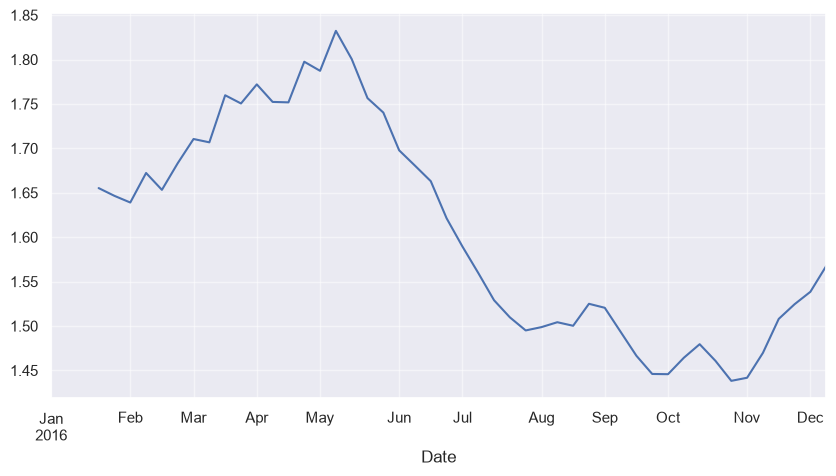

In [66]:
plt.figure(figsize=(10, 5))
rolling_ax = avocado_full_chicago_rolling.plot()

In [63]:
avocado_full_chicago_ewm = avocado_full_chicago['AveragePrice'].ewm(span=4).mean()

avocado_full_chicago_ewm

Date
2016-01-03    1.633000
2016-01-10    1.656125
2016-01-17    1.638204
2016-01-24    1.665224
2016-01-31    1.636067
2016-02-07    1.637717
2016-02-14    1.685570
2016-02-21    1.659301
2016-02-28    1.683019
2016-03-06    1.709572
2016-03-13    1.721386
2016-03-20    1.766129
2016-03-27    1.732033
2016-04-03    1.773252
2016-04-10    1.727930
2016-04-17    1.769170
2016-04-24    1.807108
2016-05-01    1.801864
2016-05-08    1.817120
2016-05-15    1.771870
2016-05-22    1.738321
2016-05-29    1.734593
2016-06-05    1.708755
2016-06-12    1.679253
2016-06-19    1.654752
2016-06-26    1.617651
2016-07-03    1.587791
2016-07-10    1.559074
2016-07-17    1.533445
2016-07-24    1.514067
2016-07-31    1.502040
2016-08-07    1.513624
2016-08-14    1.514974
2016-08-21    1.496585
2016-08-28    1.531151
2016-09-04    1.523890
2016-09-11    1.477934
2016-09-18    1.431161
2016-09-25    1.459096
2016-10-02    1.480258
2016-10-09    1.481355
2016-10-16    1.457613
2016-10-23    1.444968
2016-1

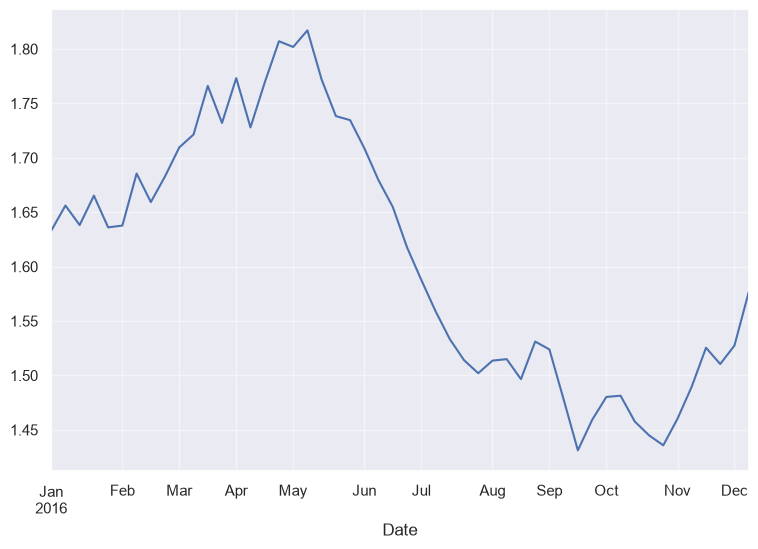

In [65]:
ewm_ax = avocado_full_chicago_ewm.plot()

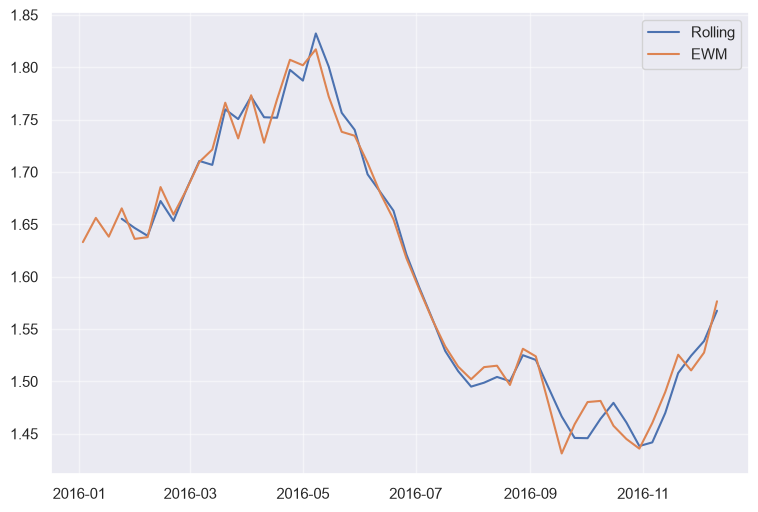

In [69]:
plt.plot(avocado_full_chicago_rolling, label='Rolling')
plt.plot(avocado_full_chicago_ewm, label='EWM')
plt.legend()

In [13]:
df_delays = pd.read_csv('delays.csv')
df_delays.head()

,client_id,company_id,delay,revenue
0,4440,9285,6 days 22:30:45,71014
1,7559,3902,2 days 10:13:45,388659
2,3694,5383,0 days 20:57:31,749818
3,5200,8742,0 days 13:32:11,887453
4,1945,429,2 days 08:22:36,848822


In [14]:
df_delays.dtypes

client_id     int64
company_id    int64
delay           str
revenue       int64
dtype: object

In [15]:
minus = df_delays[df_delays['delay'].str.contains('-', na=False)]
minus

,client_id,company_id,delay,revenue
13,9560,2730,-0 days 03:34:47,285712
19,9509,965,-0 days 03:23:24,655280
21,8967,6859,-0 days 02:07:42,340340
26,7114,8536,-0 days 07:43:17,813492
105,5676,3963,-0 days 11:36:12,581406
132,3462,8535,-0 days 09:29:10,758645
141,2002,669,-0 days 09:54:38,976623
145,4033,3259,-0 days 07:52:23,894520
156,9249,5776,-0 days 07:15:00,987243
187,1587,4981,-0 days 09:01:58,521314


In [16]:
df_delays.delay = df_delays.delay.str.replace('-', '')
print(df_delays.head(55))

    client_id  company_id            delay  revenue
0        4440        9285  6 days 22:30:45    71014
1        7559        3902  2 days 10:13:45   388659
2        3694        5383  0 days 20:57:31   749818
3        5200        8742  0 days 13:32:11   887453
4        1945         429  2 days 08:22:36   848822
5        8390        6179  0 days 17:51:19   479966
6        1761        7221  0 days 22:42:30   895316
7        9470         471  0 days 19:41:30   721705
8        4770        1890  1 days 23:41:02    69028
9        3675        9126  1 days 23:03:23   860872
10       5139        4202  1 days 19:51:00   631621
11       6620        4913  0 days 00:05:58   969550
12       9728        4419  1 days 01:30:32   435063
13       9560        2730  0 days 03:34:47   285712
14       6979         527  2 days 08:52:10   115621
15       9786        3525  2 days 21:42:12   163233
16       2998        9073  1 days 09:24:14   806357
17       1181        7692  1 days 02:41:35   673763
18       714

In [17]:
df_delays['delay'] = pd.to_timedelta(df_delays['delay'], errors='coerce')

In [18]:
df_delays.dtypes

client_id               int64
company_id              int64
delay         timedelta64[us]
revenue                 int64
dtype: object

In [19]:
print(df_delays['delay'].mean())

1 days 10:48:22.839000


In [20]:
df_delays['delay'].min(), df_delays['delay'].max()

(Timedelta('0 days 00:02:35'), Timedelta('6 days 23:21:12'))

In [21]:
df_delays['delay_categorical'] = pd.cut(df_delays['delay'], bins = 3)

In [22]:
df_delays.head()

,client_id,company_id,delay,revenue,delay_categorical
0,4440,9285,6 days 22:30:45,71014,"(4 days 15:34:59.666666, 6 days 23:21:12]"
1,7559,3902,2 days 10:13:45,388659,"(2 days 07:48:47.333333, 4 days 15:34:59.666666]"
2,3694,5383,0 days 20:57:31,749818,"(-1 days +23:52:32.683000, 2 days 07:48:47.333..."
3,5200,8742,0 days 13:32:11,887453,"(-1 days +23:52:32.683000, 2 days 07:48:47.333..."
4,1945,429,2 days 08:22:36,848822,"(2 days 07:48:47.333333, 4 days 15:34:59.666666]"


In [23]:
df_delays['delay_categorical'] = pd.cut(df_delays['delay'], bins= [pd.Timedelta(days=0), pd.Timedelta(days=1), pd.Timedelta(days=2), pd.Timedelta(days=3), pd.Timedelta(days=4), pd.Timedelta(days=5), pd.Timedelta(days=6), pd.Timedelta(days=7)], labels = ['less than 1 day', '1-2 days', '2-3 days', '3-4 days', '4-5 days', '5-6 days', 'more than 6 days'])

In [24]:
df_delays.head()

,client_id,company_id,delay,revenue,delay_categorical
0,4440,9285,6 days 22:30:45,71014,more than 6 days
1,7559,3902,2 days 10:13:45,388659,2-3 days
2,3694,5383,0 days 20:57:31,749818,less than 1 day
3,5200,8742,0 days 13:32:11,887453,less than 1 day
4,1945,429,2 days 08:22:36,848822,2-3 days


In [25]:
for_figure = df_delays['delay_categorical'].value_counts().reset_index()

for_figure

,delay_categorical,count
0,less than 1 day,500
1,1-2 days,260
2,2-3 days,150
3,3-4 days,28
4,more than 6 days,28
5,4-5 days,17
6,5-6 days,17


In [26]:
fig = px.bar(for_figure, x = 'delay_categorical', y = 'count')
fig.show()